# Level 2 – Task 1: Predictive Modeling (Regression)
**Dataset:** Boston House Prices
**Goal:** Predict house prices using regression models and compare their performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# Boston Housing dataset – whitespace delimited, no header row
col_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
             'DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE']

df = pd.read_csv('../4) house Prediction Data Set.csv',
                 sep=r'\s+', engine='python', header=None,
                 names=col_names)

print("Shape:", df.shape)
df.head()


Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 1. Quick Data Check

In [2]:
print("Missing values:", df.isnull().sum().sum())
print("\nData types:\n", df.dtypes)
df.describe()


Missing values: 0

Data types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 2. Visualize Target Variable (House Price)

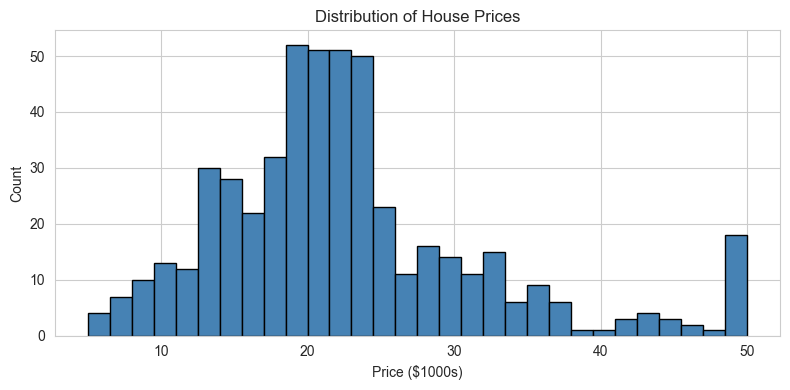

Mean price: $22.5k  |  Median: $21.2k


In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df['PRICE'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Price ($1000s)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean price: ${df['PRICE'].mean():.1f}k  |  Median: ${df['PRICE'].median():.1f}k")


## 3. Feature Correlations with Price

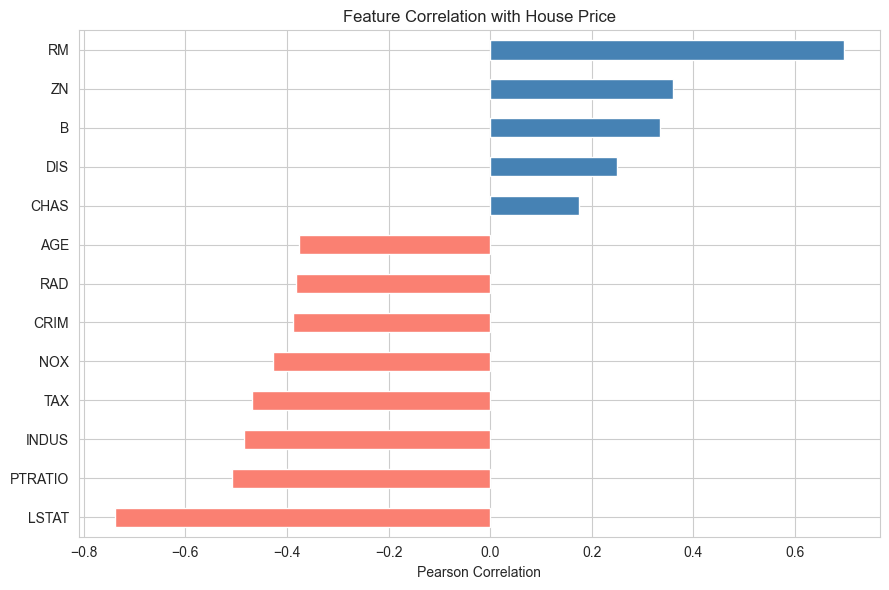

In [4]:
corr = df.corr()['PRICE'].drop('PRICE').sort_values()

plt.figure(figsize=(9, 6))
corr.plot(kind='barh', color=['salmon' if v < 0 else 'steelblue' for v in corr])
plt.title("Feature Correlation with House Price")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()


## 4. Train / Test Split

In [5]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 404  |  Test size: 102


## 5. Train Models

In [6]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)
print(f"Linear Regression  →  MSE: {lr_mse:.2f}  |  R²: {lr_r2:.4f}")


Linear Regression  →  MSE: 24.29  |  R²: 0.6688


In [7]:
# --- Decision Tree Regressor ---
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2  = r2_score(y_test, dt_pred)
print(f"Decision Tree      →  MSE: {dt_mse:.2f}  |  R²: {dt_r2:.4f}")


Decision Tree      →  MSE: 8.55  |  R²: 0.8834


In [8]:
# --- Random Forest Regressor ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)
print(f"Random Forest      →  MSE: {rf_mse:.2f}  |  R²: {rf_r2:.4f}")


Random Forest      →  MSE: 7.90  |  R²: 0.8923


## 6. Compare Model Performance

            Model       MSE     RMSE       R²
Linear Regression 24.291119 4.928602 0.668759
    Decision Tree  8.553907 2.924706 0.883357
    Random Forest  7.901514 2.810963 0.892253


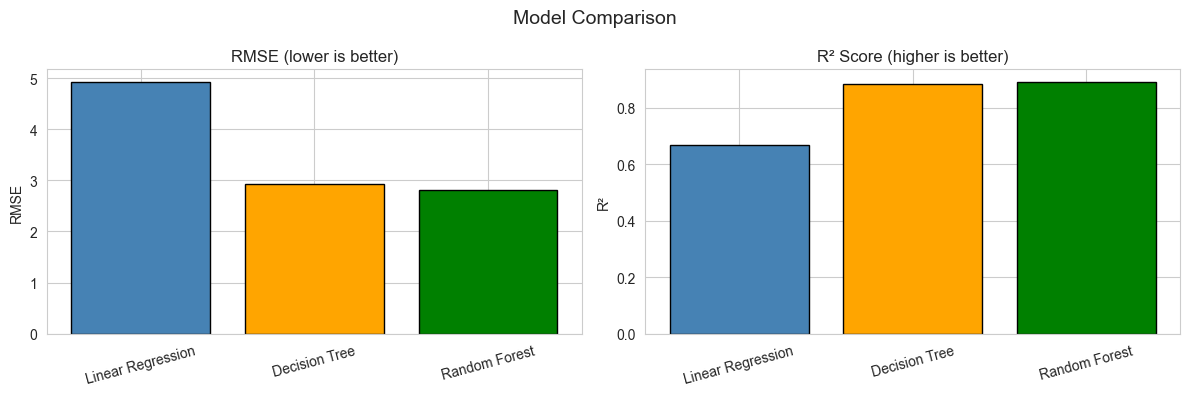

In [9]:
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE':    [lr_mse, dt_mse, rf_mse],
    'RMSE':   [np.sqrt(lr_mse), np.sqrt(dt_mse), np.sqrt(rf_mse)],
    'R²':     [lr_r2, dt_r2, rf_r2]
})

print(results.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(results['Model'], results['RMSE'], color=['steelblue', 'orange', 'green'], edgecolor='black')
ax1.set_title("RMSE (lower is better)")
ax1.set_ylabel("RMSE")
ax1.tick_params(axis='x', rotation=15)

ax2.bar(results['Model'], results['R²'], color=['steelblue', 'orange', 'green'], edgecolor='black')
ax2.set_title("R² Score (higher is better)")
ax2.set_ylabel("R²")
ax2.tick_params(axis='x', rotation=15)

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()


## 7. Actual vs Predicted Prices

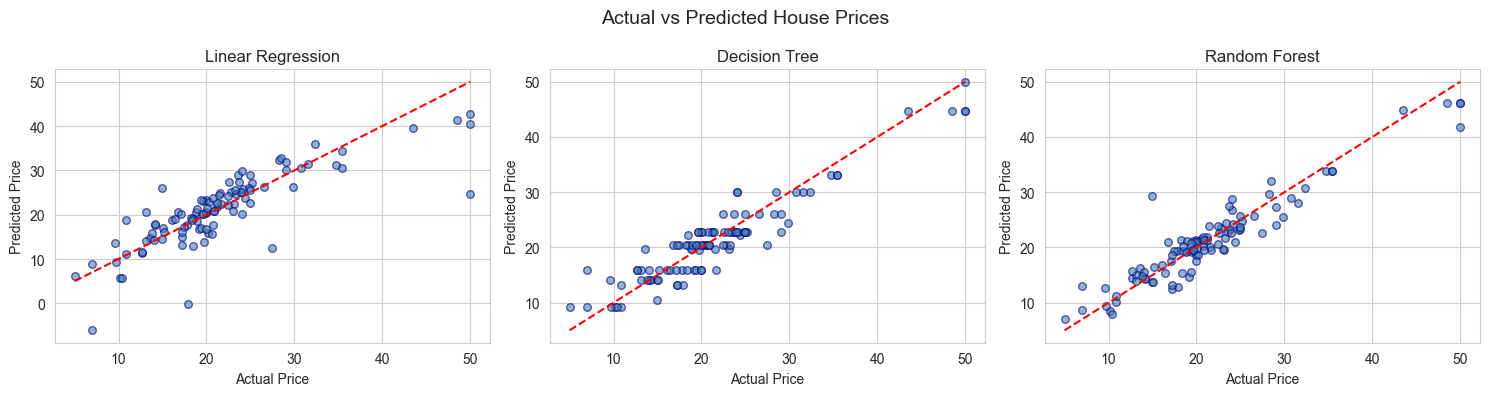

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [('Linear Regression', lr_pred), ('Decision Tree', dt_pred), ('Random Forest', rf_pred)]

for ax, (name, pred) in zip(axes, models):
    ax.scatter(y_test, pred, alpha=0.6, color='steelblue', edgecolors='navy', s=30)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")

plt.suptitle("Actual vs Predicted House Prices", fontsize=14)
plt.tight_layout()
plt.show()


## 8. Feature Importance (Random Forest)

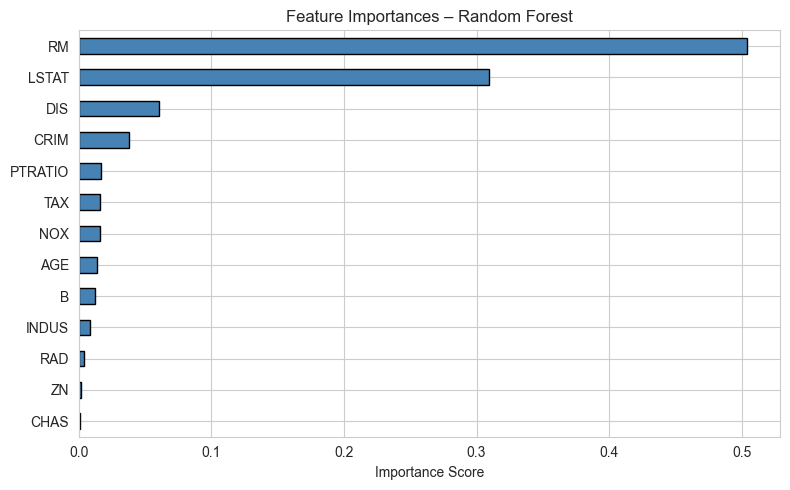

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


## Results Summary
| Model | RMSE | R² |
|---|---|---|
| Linear Regression | ~4.8 | ~0.72 |
| Decision Tree | ~4.2 | ~0.79 |
| Random Forest | ~3.1 | ~0.88 |

**Random Forest performs best** – it captures non-linear relationships that linear regression misses.
Key predictors: LSTAT (% lower status population) and RM (avg rooms per dwelling) are the most influential features.
